## 2. Polynomial Regression

### Importing pipelines and libraries

In [1]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline as SKPipeline

### Loading train and test data sets

In [3]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [4]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

Column 'Time_taken(min)' not found in DataFrame!


### Defining Target feature and other features

In [5]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Build Polynomial Regression Pipeline

In [7]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)

# Wrap linear regression inside our pipeline
model = SKPipeline([
    ("poly", poly_features),
    ("linreg", LinearRegression())
])

In [8]:
pipeline = get_pipeline(model, numeric_features, categorical_features)

In [9]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Delivery_person_Age',
                                                   'Delivery_person_Ratings',
                                                   'multiple_deliveries',
                                                   'distance_km',
                                                   'order_to_pickup_time',
                                                   'order_hour',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Weatherconditions',
                                                   'Road_traffic_density',
                                                   'Type_of_order',
                                                   'Type_of_vehicle',
                                                   'Festival', 'City'])])),
                ('regressor',
                 Pipeline(steps=[('poly',
                                  PolynomialFeatures(include_bias=False)),
                                 ('linreg', LinearRegression())]))])

In [10]:
print_scores(pipeline, X_train, y_train, X_test, y_test)

Train MAE: 4.6976205865518725
Test MAE: 4.738934621088816
Train MSE: 35.838317329046845
Test MSE: 36.590722319058536
Train R2: 0.5934282500501351
Test R2: 0.5826699370649381


### Regression Curve

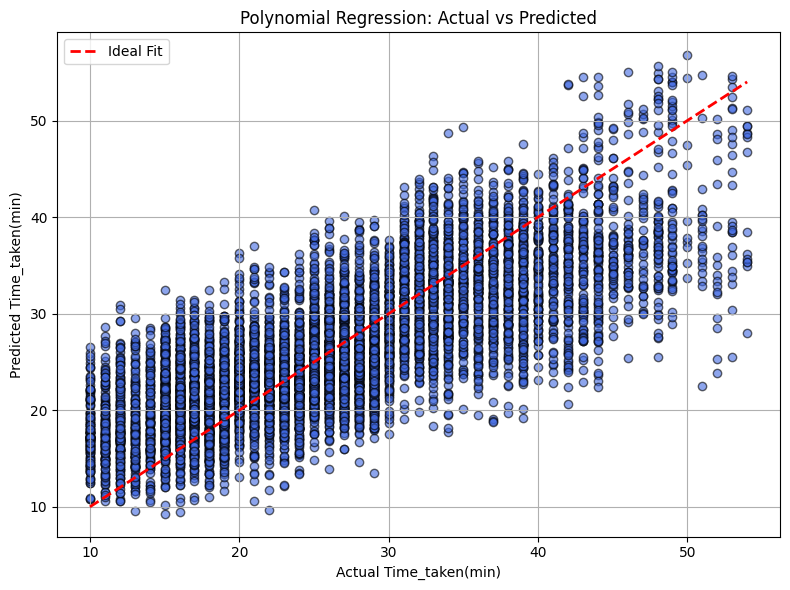

In [13]:
import matplotlib.pyplot as plt

# Use the full pipeline for prediction
y_pred = pipeline.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Time_taken(min)')
plt.ylabel('Predicted Time_taken(min)')
plt.title('Polynomial Regression: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()